In [59]:
import sys
from pathlib import Path
ROOT = Path('../').absolute()
sys.path.insert(0, str(ROOT / "src" / "experimental"))
sys.path.insert(0, str(ROOT / "scripts" / "neural"))

import ipynbname
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from neural.data import load_data, sample_indices, build_splits
from yumeow_plot import get_fig
from argparse import Namespace

args = Namespace(
    data_dir=ROOT / "data" / "neural" / "data",
    normalize=True,
    sampling_hz=4.0,
    save_path=ROOT / "logs" / "neural" / ipynbname.name()
)
Path(args.save_path).mkdir(parents=True, exist_ok=True)
data, node_info, time_info = load_data(args)

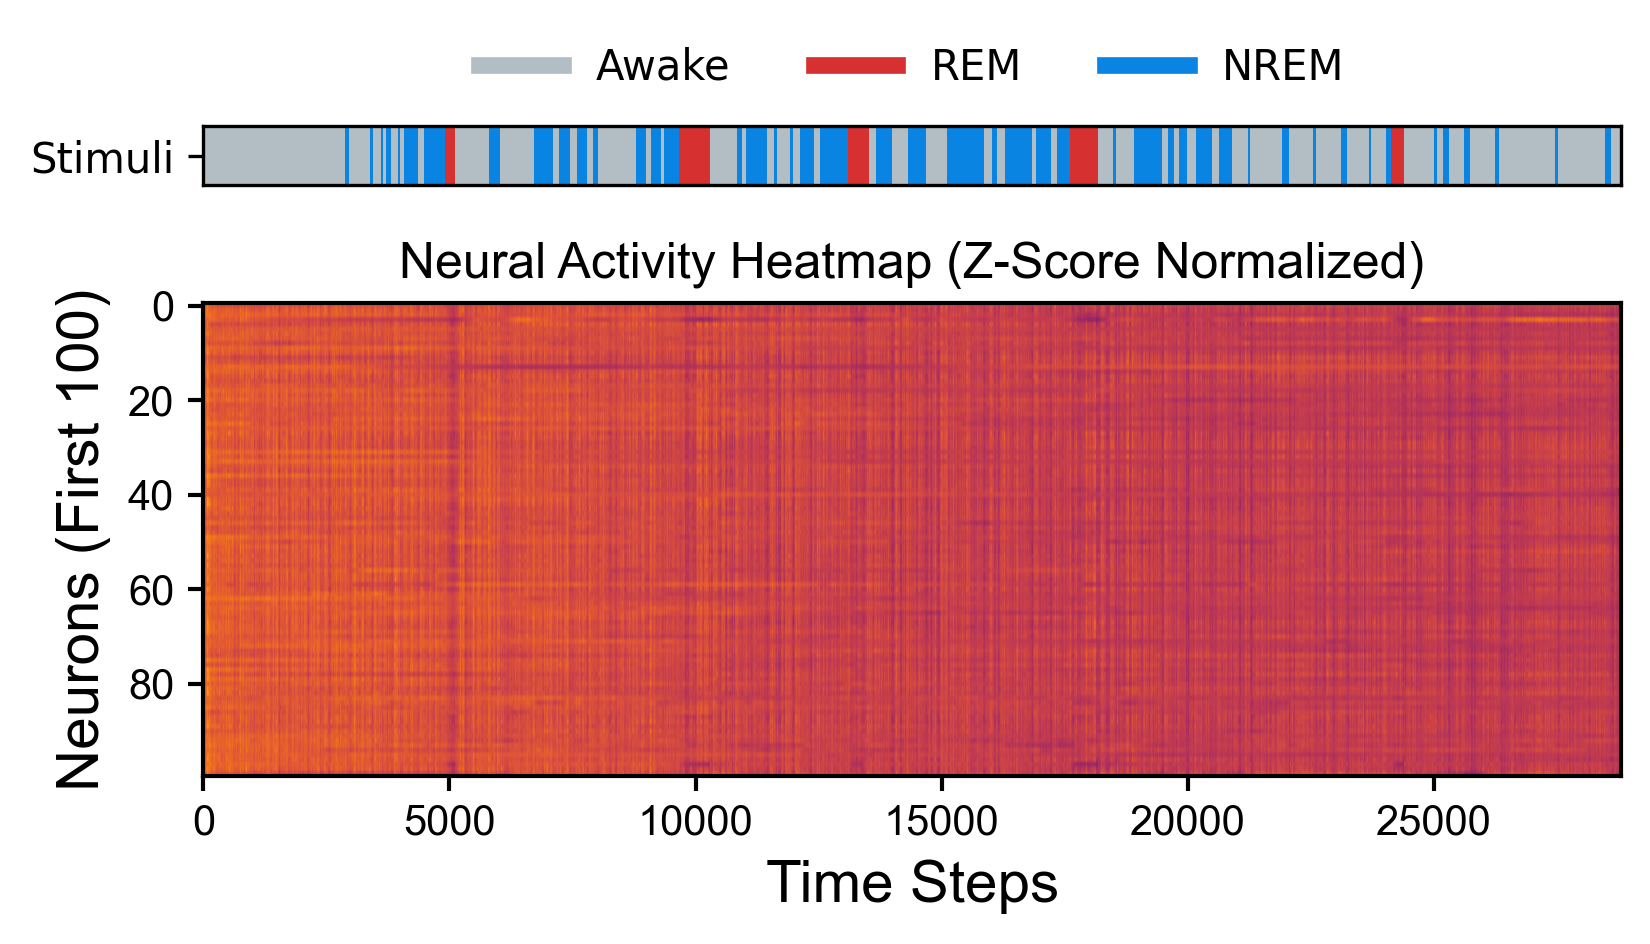

In [81]:
fig, axes = get_fig(1, 1, AW=12, AH=4, TM=5)
ax = axes[0]
ax.imshow(data.T[:100, :], aspect='auto', cmap='inferno')
ax.set_xlabel('Time Steps')
ax.set_ylabel('Neurons (First 100)')
ax.set_title('Neural Activity Heatmap (Z-Score Normalized)')

top_ax = fig.add_axes(ax.get_side_rect('top', pad_cm=1, fixed_cm=0.5))
im = top_ax.imshow(
    time_info['stimuli'].map(lambda x: ['Awake', 'REM', 'NREM'].index(x)).values[np.newaxis, :], 
    aspect='auto', 
    cmap=plt.cm.colors.ListedColormap(['#b2bec3', '#d63031', '#0984e3']), 
    vmin=0, vmax=2, 
    interpolation='nearest'
)
top_ax.set_xticks([])
top_ax.set_yticks([0.0])
top_ax.set_yticklabels(['Stimuli'])
top_ax.legend(
    handles=[
        plt.Line2D([0], [0], color='#b2bec3', lw=4, label='Awake'),
        plt.Line2D([0], [0], color='#d63031', lw=4, label='REM'),
        plt.Line2D([0], [0], color='#0984e3', lw=4, label='NREM'),
    ],
    loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.0),
)

# top_ax.imshow()

fig.savefig(Path(args.save_path) / "neural_activity_heatmap.png", dpi=300, bbox_inches='tight')
display(fig)

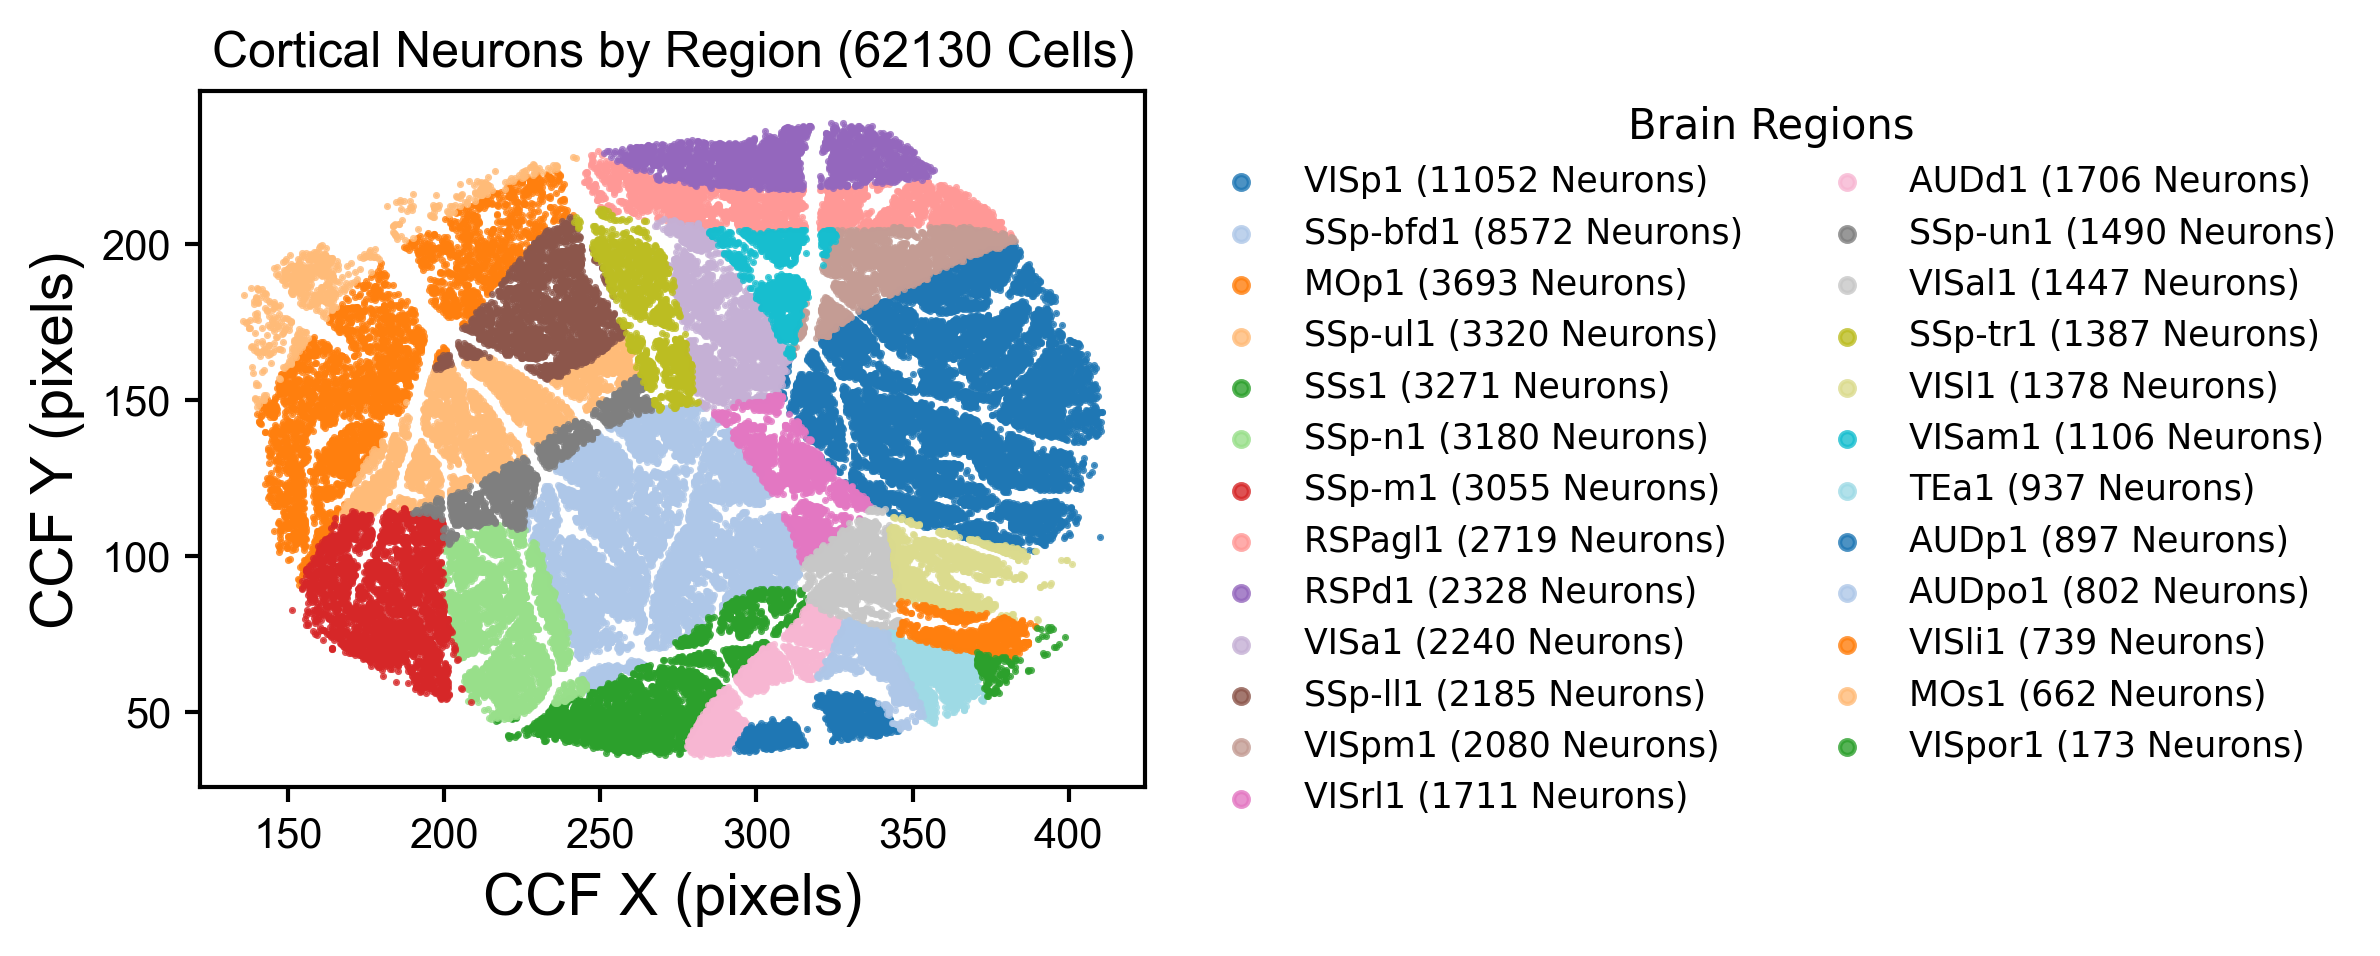

In [82]:
fig, axes = get_fig(1, 1, AW=8, AH=6, dpi=300)
ax = axes[0]

# 获取所有唯一的 ID，并按包含神经元数量排序（为了图例好看）
unique_names = np.unique(node_info['acs'])
counts = [np.sum(node_info['acs'] == name) for name in unique_names]
sorted_ids = unique_names[np.argsort(counts)[::-1]]

cmap = plt.get_cmap('tab20')
for idx, name in enumerate(sorted_ids):
    mask = (node_info['acs'] == name)
    ax.scatter(
        node_info['coords_2d_x'][mask][::1], 
        node_info['coords_2d_y'][mask][::1], 
        s=0.5,
        alpha=0.8,
        color=cmap(idx % 20),
        label=f"{name} ({np.sum(mask)} Neurons)",
    )
ax.set_title(f'Cortical Neurons by Region ({len(node_info)} Cells)')
ax.set_xlabel('CCF X (pixels)')
ax.set_ylabel('CCF Y (pixels)')
ax.set_aspect('equal')
ax.legend(
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    borderaxespad=0., 
    title="Brain Regions", 
    markerscale=5, 
    fontsize='small', 
    ncol=2,
    frameon=False,
)

fig.savefig(Path(args.save_path) / "neuron_spatial_distribution.png", dpi=300, bbox_inches='tight')
display(fig)

In [ ]:
fig, axes = get_fig(1, 1, AW=8, AH=6, dpi=300)
ax = axes[0]

# 获取所有唯一的 ID，并按包含神经元数量排序（为了图例好看）
unique_names = np.unique(node_info['acs'])
counts = [np.sum(node_info['acs'] == name) for name in unique_names]
sorted_ids = unique_names[np.argsort(counts)[::-1]]

cmap = plt.get_cmap('tab20')
for idx, name in enumerate(sorted_ids):
    mask = (node_info['acs'] == name)
    ax.scatter(
        node_info['coords_2d_x'][mask][::1], 
        node_info['coords_2d_y'][mask][::1], 
        s=0.5,
        alpha=0.8,
        color=cmap(idx % 20),
        label=f"{name} ({np.sum(mask)} Neurons)",
    )
ax.set_title(f'Cortical Neurons by Region ({len(node_info)} Cells)')
ax.set_xlabel('CCF X (pixels)')
ax.set_ylabel('CCF Y (pixels)')
ax.set_aspect('equal')
ax.legend(
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    borderaxespad=0., 
    title="Brain Regions", 
    markerscale=5, 
    fontsize='small', 
    ncol=2,
    frameon=False,
)

fig.savefig(Path(args.save_path) / "neuron_spatial_distribution.png", dpi=300, bbox_inches='tight')
display(fig)

In [94]:
from scipy.ndimage import gaussian_filter

dpm = 3  # 每多少像素一个网格单元, 越大越粗糙但越快
x = node_info['coords_2d_x']
y = node_info['coords_2d_y']

nx = int(np.ceil((x.max() - x.min()) / dpm))
ny = int(np.ceil((y.max() - y.min()) / dpm))
x_edges = np.linspace(x.min(), x.max(), nx + 1)
y_edges = np.linspace(y.min(), y.max(), ny + 1)
ix = np.clip(np.digitize(x, x_edges) - 1, 0, nx - 1)
iy = np.clip(np.digitize(y, y_edges) - 1, 0, ny - 1)
flat_idx = iy * nx + ix
counts = np.bincount(flat_idx, minlength=nx * ny).astype(np.float32)
counts_safe = counts.copy()
counts_safe[counts_safe == 0] = 1.0
brain_mask = counts.reshape(ny, nx) > 0


def project_frame(activity_1d, sigma=1.0):
    """
    activity_1d: shape (N,)
    return: 2D image of shape (ny, nx)
    """
    # 按像素/网格聚合神经元活动
    summed = np.bincount(
        flat_idx,
        weights=activity_1d.astype(np.float32),
        minlength=nx * ny
    ).astype(np.float32)

    img = (summed / counts_safe).reshape(ny, nx)

    # 可选：轻微平滑，让空间图更连续
    if sigma is not None and sigma > 0:
        img = gaussian_filter(img, sigma=sigma)

    # 把脑外区域 mask 掉
    img = np.ma.array(img, mask=~brain_mask)
    return img

In [95]:
# 选一个片段，中心在全局活动峰值附近
T, N = data.shape
global_signal = np.asarray(data.mean(axis=1)).ravel()
center = int(np.argmax(global_signal))
fps_data = 4.0
half_window_sec = 20
half_window = int(half_window_sec * fps_data)
start = max(0, center - half_window)
end = min(T, center + half_window)

In [102]:
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter

frame_idx = np.arange(start, end, 1)   # 如果还嫌长，可以改成 step=2
display_fps = 10                       # 输出视频帧率
smooth_radius = 1                      # 当前帧前后各 1 帧做均值，相当于 3 帧平滑
sigma = 1.0                            # 空间平滑参数，越大越模糊

def get_activity_at(t):
    lo = max(0, t - smooth_radius)
    hi = min(T, t + smooth_radius + 1)
    return np.asarray(data[lo:hi].mean(axis=0)).ravel()

fig, axes = get_fig(1, 1, AW=8, AH=6, dpi=300, TM=5, BM=7, RM=7, LM=7)
ax = axes[0]
cax = fig.add_axes(ax.get_side_rect('right', pad_cm=0.5, fixed_cm=0.5))
ax_state = fig.add_axes(ax.get_side_rect('bottom', pad_cm=1.5, fixed_cm=0.5))


# 主图初始帧
sample_ts = np.linspace(start, end - 1, min(50, end - start), dtype=int)
sample_imgs = np.stack([project_frame(get_activity_at(t), sigma=sigma).filled(np.nan) for t in sample_ts])
vmin = np.nanpercentile(sample_imgs, 5)
vmax = np.nanpercentile(sample_imgs, 95)
img0 = project_frame(get_activity_at(frame_idx[0]), sigma=sigma)
im = ax.imshow(
    img0,
    origin="lower",
    cmap='inferno',
    vmin=vmin, vmax=vmax,
    interpolation="nearest",
    extent=(x_edges[0], x_edges[-1], y_edges[0], y_edges[-1])
)

ax.set_xlabel('CCF X (pixels)', fontsize=0.7*fig.figinfo['fontsize'])
ax.set_ylabel('CCF Y (pixels)', fontsize=0.7*fig.figinfo['fontsize'])
ax.set_title("Cortex-wide Neural Activity")

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Neural Activity (Smoothed)")

# 底部状态条（仅显示当前片段）
ax_state.imshow(
    time_info["stimuli"].map(lambda x: ["Awake", "REM", "NREM"].index(x)).values[np.newaxis, start:end],
    aspect="auto",
    cmap=plt.cm.colors.ListedColormap(["#b2bec3", "#d63031", "#0984e3"]),
    vmin=0, vmax=2,
    interpolation="nearest",
    extent=(start, end, 0, 1)
)
ax_state.set_yticks([0])
ax_state.set_yticklabels(["Stimuli"])
ax_state.set_xlabel("Time Steps", fontsize=0.7*fig.figinfo['fontsize'])
ax_state.legend(
    handles=[
        plt.Line2D([0], [0], color='#b2bec3', lw=4, label='Awake'),
        plt.Line2D([0], [0], color='#d63031', lw=4, label='REM'),
        plt.Line2D([0], [0], color='#0984e3', lw=4, label='NREM'),
    ],
    loc='center left', ncol=1, frameon=False, bbox_to_anchor=(1.0, 0.5),
)
cursor = ax_state.axvline(start, color="white", lw=1.5)

# 状态文本和时间文本
state_text = ax.text(
    0.02, 0.98, "",
    transform=ax.transAxes,
    va="top", ha="left",
    color="white",
    fontsize=11,
    bbox=dict(facecolor="black", alpha=0.4, edgecolor="none", pad=3)
)
time_text = ax.text(
    0.98, 0.98, "",
    transform=ax.transAxes,
    va="top", ha="right",
    color="white",
    fontsize=11,
    bbox=dict(facecolor="black", alpha=0.4, edgecolor="none", pad=3)
)
from tqdm import tqdm
pbar = tqdm(total=len(frame_idx), desc="Generating frames for animation")

def update(i):
    t = frame_idx[i]
    act = get_activity_at(t)
    img = project_frame(act, sigma=1.0)
    im.set_data(img)
    cursor.set_xdata([t, t])
    state = time_info["stimuli"].iat[t]
    state_text.set_text(f"State: {state}")
    time_text.set_text(f"t = {t}  ({t / fps_data:.1f} s)")

    pbar.update(1)
    pbar.refresh()
    return im, cursor, state_text, time_text

ani = FuncAnimation(
    fig,
    update,
    frames=len(frame_idx),
    interval=1000 / display_fps,
    blit=True
)

# gif 适合 README 直接嵌入，但体积会比较大
gif_path = Path(args.save_path) / "cortex_activity.gif"
ani.save(gif_path, writer=PillowWriter(fps=display_fps))

plt.close(fig)

Generating frames for animation: 163it [00:16,  9.19it/s]                         